In [41]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

print("Imported Successfully")

Imported Successfully


In [42]:
# !unzip data.zip

In [43]:
# images = []
# masks = []

image_path = "data/Body/Images"
mask_path = "data/Body/Masks"

image_files = sorted([f for f in os.listdir(image_path) if not f.startswith('.')])
mask_files = sorted([f for f in os.listdir(mask_path) if not f.startswith('.')])

# if len(image_files) != len(mask_files):
#     print(f" Warning: Mismatch in counts! Images: {len(image_files)}, Masks: {len(mask_files)}")

# for img_file, mask_file in zip(image_files, mask_files):

#     full_img_path = os.path.join(image_path, img_file)
#     full_mask_path = os.path.join(mask_path, mask_file)

#     img = cv2.imread(full_img_path)
#     mask = cv2.imread(full_mask_path, cv2.IMREAD_GRAYSCALE)

#     if img is None:
#         print(f"Skipping: Could not load image file -> {img_file}")
#         continue
#     if mask is None:
#         print(f"Skipping: Could not load mask file -> {mask_file}")
#         continue

#     img = cv2.resize(img, (128,128))
#     mask = cv2.resize(mask, (128,128))

#     images.append(img)
#     masks.append(mask)

# X = np.array(images) / 255.0
# y = np.array(masks) / 255.0

# y = np.expand_dims(y, axis=-1)

# print("Images shape (X):", X.shape)
# print("Masks shape (y):", y.shape)

import os
import numpy as np

IMG_HEIGHT = 512
IMG_WIDTH = 512

images = []
masks = []

for img_file, mask_file in zip(image_files, mask_files):

    img_path = os.path.join(image_path, img_file)
    mask_path_full = os.path.join(mask_path, mask_file)

    try:
        img = np.fromfile(img_path, dtype=np.float32)
        img = img.reshape((512, 512))

        mask = np.fromfile(mask_path_full, dtype=np.float32)
        mask = mask.reshape((512, 512))

        images.append(img)
        masks.append(mask)

    except Exception as e:
        print(f"Skipping {img_file}: {e}")

X = np.array(images)
y = np.array(masks)

print("Images shape:", X.shape)
print("Masks shape:", y.shape)

Images shape: (500, 512, 512)
Masks shape: (500, 512, 512)


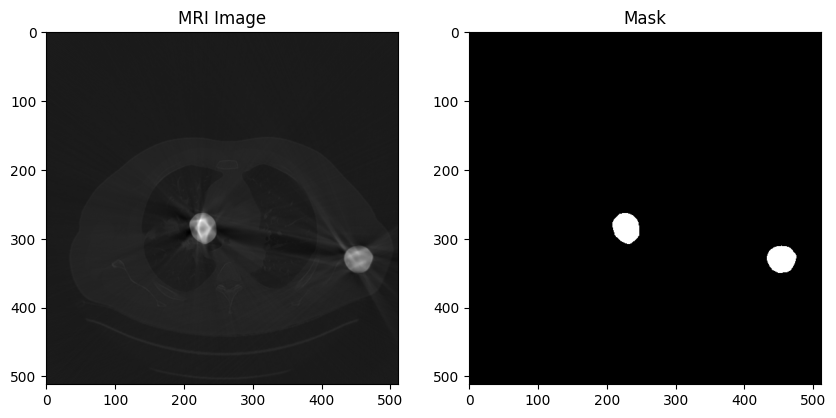

In [44]:
# plt.figure(figsize=(10,5))

# for i in range(3):

#     plt.subplot(3,2,2*i+1)
#     plt.imshow(X[i])
#     plt.title("MRI Image")
#     plt.axis("off")

#     plt.subplot(3,2,2*i+2)
#     plt.imshow(y[i].squeeze(), cmap='gray')
#     plt.title("Metal Mask")
#     plt.axis("off")

# plt.show()

import matplotlib.pyplot as plt

idx = 0

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(X[idx], cmap='gray')
plt.title("MRI Image")

plt.subplot(1,2,2)
plt.imshow(y[idx], cmap='gray')
plt.title("Mask")

plt.show()

In [45]:
X = X.astype("float32")

X = (X - X.min()) / (X.max() - X.min())
# print(np.unique(y))

X = X[..., np.newaxis]
y = y[..., np.newaxis]

print(X.shape)
print(y.shape)


(500, 512, 512, 1)
(500, 512, 512, 1)


In [46]:

X_resized = []
y_resized = []

for img, mask in zip(X.squeeze(), y.squeeze()):

    img_r = cv2.resize(img, (128,128))
    mask_r = cv2.resize(mask, (128,128),
                        interpolation=cv2.INTER_NEAREST)

    X_resized.append(img_r)
    y_resized.append(mask_r)

X = np.array(X_resized)[..., np.newaxis]
y = np.array(y_resized)[..., np.newaxis]

print(X.shape)
print(y.shape)

(500, 128, 128, 1)
(500, 128, 128, 1)


In [47]:
inputs = Input((128,128,1))
# def build_unet(input_shape=(128,128,1)):
#     inputs = Input(input_shape)

# Encoder
c1 = Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
p1 = MaxPooling2D((2,2))(c1)

c2 = Conv2D(32, (3,3), activation='relu', padding='same')(p1)
p2 = MaxPooling2D((2,2))(c2)

# Bottleneck
b1 = Conv2D(64, (3,3), activation='relu', padding='same')(p2)

# Decoder
u1 = UpSampling2D((2,2))(b1)
merge1 = Concatenate()([u1, c2])
c3 = Conv2D(32, (3,3), activation='relu', padding='same')(merge1)

u2 = UpSampling2D((2,2))(c3)
merge2 = Concatenate()([u2, c1])
c4 = Conv2D(16, (3,3), activation='relu', padding='same')(merge2)

outputs = Conv2D(1, (1,1), activation='sigmoid')(c4)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 128, 128,  │        160 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_8[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, 64, 64,    │          0 │ conv2d_26[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 64, 64,    │          0 │ up_sampling2d_8[… │
│ (Concatenate)       │ 96)               │            │ conv2d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 64, 64,    │     27,680 │ concatenate_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_9     │ (None, 128, 128,  │          0 │ conv2d_27[0][0]   │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 128, 128,  │          0 │ up_sampling2d_9[… │
│ (Concatenate)       │ 48)               │            │ conv2d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 128, 128,  │      6,928 │ concatenate_9[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 128, 128,  │         17 │ conv2d_28[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 57,921 (226.25 KB)

 Trainable params: 57,921 (226.25 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# X_train_val, X_test_val, y_train_val, y_test_val = train_test_split(
#     X_train,
#     y_train,
#     test_size=0.2,
#     random_state=42
# )

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.8373 - loss: 0.6101 - val_accuracy: 0.9970 - val_loss: 0.3065
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.9968 - loss: 0.0936 - val_accuracy: 0.9970 - val_loss: 0.0623
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.9968 - loss: 0.0699 - val_accuracy: 0.9970 - val_loss: 0.0523
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.9968 - loss: 0.0436 - val_accuracy: 0.9970 - val_loss: 0.0321
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9968 - loss: 0.0344 - val_accuracy: 0.9970 - val_loss: 0.0309
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9968 - loss: 0.0324 - val_accuracy: 0.9970 - val_loss: 0.0300
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.9968 - loss: 0.0313 - val_accuracy: 0.9970 - val_loss: 0.0287
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.9968 - loss: 0.0296 - val_accuracy: 0.9970 - val_loss:

In [52]:
prediction = model.predict(
    np.expand_dims(X_test[4], axis=0)
)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


In [50]:
# binary_prediction = (prediction.squeeze() > 0.5).astype(int)

# Use this binary prediction in your plot
# plt.imshow(binary_prediction, cmap='gray')

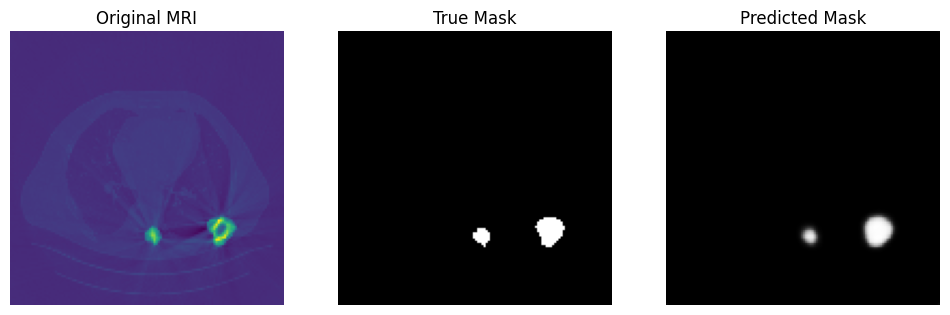

In [53]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_test[4])
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(y_test[4].squeeze(), cmap='gray')
plt.title("True Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(prediction.squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()